# 06 – FFT Analysis of ECG Chunks

**Label mapping (WESAD dataset)**

| Raw label | Condition   | Binary class |
|-----------|-------------|---------------|
| 1         | Baseline    | 0 – No Stress |
| 2         | Stress      | 1 – Stress    |
| 3         | Amusement   | 0 – No Stress |
| 4         | Meditation  | 1 – Stress    |

This notebook:
1. Loads WESAD data and chunks it at **30 s / 120 s / 300 s**.
2. Computes FFT for each chunk using `Features.compute_fft()`.
3. Plots mean FFT spectra for all three chunk durations (stress vs. non-stress) **together** on one figure.
4. Computes **cosine similarity** between:
   - Stress ↔ Non-stress (cross-class)
   - Stress ↔ Stress (within stress)
   - Non-stress ↔ Non-stress (within non-stress)

   …and visualises the distributions for all three chunk sizes.

## 0 · Imports & setup

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import os
import sys
import warnings
from pathlib import Path
from scipy.spatial.distance import cosine   # cosine distance → similarity = 1 - distance
from itertools import combinations

warnings.filterwarnings('ignore')

# ── adjust this to point at the project root ──────────────────────────────────
PROJECT_ROOT = Path('..')          # notebook lives in notebooks/, project root is one level up
sys.path.append(str(PROJECT_ROOT / 'src'))

from data     import Data
from features import Features

# Sampling frequency (WESAD ECG)
FS = 700

# Chunk durations to analyse
DURATIONS = [30, 120, 300]   # seconds

# WESAD raw labels that are valid (discard 0 = transition)
VALID_LABELS = [1, 2, 3, 4]

# Binary mapping: 1 = stress, 0 = no-stress
LABEL_MAP = {1: 0, 2: 1, 3: 0, 4: 1}
LABEL_NAME = {0: 'Non-Stress', 1: 'Stress'}

# Frequency axis limit for plots (Hz)
FREQ_MAX = 40

# Colour palette
COLORS = {0: '#2196F3', 1: '#F44336'}   # blue = non-stress, red = stress

data_loader       = Data(fs=FS)
feature_extractor = Features(fs=FS)

print('✅ Imports OK')
print(f'   Chunk durations : {DURATIONS} s')
print(f'   Sampling rate   : {FS} Hz')
print(f'   Label map       : {LABEL_MAP}')

✅ Imports OK
   Chunk durations : [30, 120, 300] s
   Sampling rate   : 700 Hz
   Label map       : {1: 0, 2: 1, 3: 0, 4: 1}


## 1 · Load WESAD data

In [10]:
# data_loader.load_data() returns:
#   ecgs   – list of 1D numpy arrays (one per subject)
#   labels – list of 1D numpy arrays (same length as each ECG)

dataset_path = PROJECT_ROOT / 'data' / 'WESAD'
print(f'Loading WESAD from: {dataset_path.resolve()}')

ecgs, labels = data_loader.read_dataset(str(dataset_path))
print(f'✅ Loaded {len(ecgs)} subjects')
for i, (e, l) in enumerate(zip(ecgs, labels)):
    unique, counts = np.unique(l, return_counts=True)
    dist = dict(zip(unique.astype(int), counts))
    print(f'   Subject {i+1:>2d}: {len(e):>8,} samples | label dist: {dist}')

Loading WESAD from: G:\Master\Thesis\FLT\Code\ECG-to-stress\data\WESAD


✅ Loaded 2 subjects
   Subject  1: 3,663,100 samples | label dist: {np.int64(0): np.int64(1443400), np.int64(1): np.int64(826000), np.int64(2): np.int64(476000), np.int64(3): np.int64(257600), np.int64(4): np.int64(553701), np.int64(5): np.int64(35000), np.int64(6): np.int64(36399), np.int64(7): np.int64(35000)}
   Subject  2: 4,255,300 samples | label dist: {np.int64(0): np.int64(2142701), np.int64(1): np.int64(800800), np.int64(2): np.int64(430500), np.int64(3): np.int64(253400), np.int64(4): np.int64(537599), np.int64(6): np.int64(45500), np.int64(7): np.int64(44800)}


## 2 · Chunk data and compute FFT

For each duration we:
- Keep only valid labels (1–4) and map to binary (0/1).
- Slice non-overlapping chunks of `duration × FS` samples.
- Compute FFT with `Features.compute_fft()` (cleans ECG, DC-removes, Hann window).
- Interpolate each spectrum to a common frequency grid for averaging.

In [11]:
def interpolate_spectrum(freqs, mag, common_freqs):
    """Interpolate (freqs, mag) onto common_freqs. Returns 1D array."""
    return np.interp(common_freqs, freqs, mag, left=0.0, right=0.0)


# Storage: results[duration] = {'freqs': common_grid,
#                                'spectra': {0: [mag, …], 1: [mag, …]}}
results = {}

for duration in DURATIONS:
    chunk_size  = duration * FS
    # Common frequency grid (one-sided, Hz) – use the grid of the first valid FFT
    common_freqs = np.fft.rfftfreq(chunk_size, d=1.0 / FS)
    freq_mask    = common_freqs <= FREQ_MAX
    common_freqs = common_freqs[freq_mask]

    spectra = {0: [], 1: []}   # non-stress / stress
    n_chunks = {0: 0, 1: 0}

    for ecg, label in zip(ecgs, labels):
        # Keep only valid-label samples
        valid_mask  = np.isin(label, VALID_LABELS)
        valid_ecg   = ecg[valid_mask]
        valid_label = label[valid_mask]

        for start in range(0, len(valid_ecg) - chunk_size + 1, chunk_size):
            chunk      = valid_ecg[start : start + chunk_size]
            raw_label  = int(valid_label[start])
            bin_label  = LABEL_MAP[raw_label]

            try:
                freqs_raw, mag_raw = feature_extractor.compute_fft(chunk)
                if freqs_raw.size == 0:
                    continue
                mag_interp = interpolate_spectrum(freqs_raw, mag_raw, common_freqs)
                spectra[bin_label].append(mag_interp)
                n_chunks[bin_label] += 1
            except Exception as e:
                pass   # skip bad chunks silently

    results[duration] = {
        'freqs'  : common_freqs,
        'spectra': spectra,
    }

    total = n_chunks[0] + n_chunks[1]
    print(f'{duration:>3d}s → {total:>5d} chunks  '
          f'(non-stress: {n_chunks[0]:>4d}, stress: {n_chunks[1]:>4d})')

print('\n✅ FFT computation complete')

 30s →   196 chunks  (non-stress:  103, stress:   93)
120s →    49 chunks  (non-stress:   26, stress:   23)
300s →    19 chunks  (non-stress:   10, stress:    9)

✅ FFT computation complete


## 3 · Plot mean FFT spectra – all durations together

Three panels (one per chunk duration) stacked vertically so you can directly compare how spectral content changes with window length.  
Shaded region = ±1 std across all chunks.

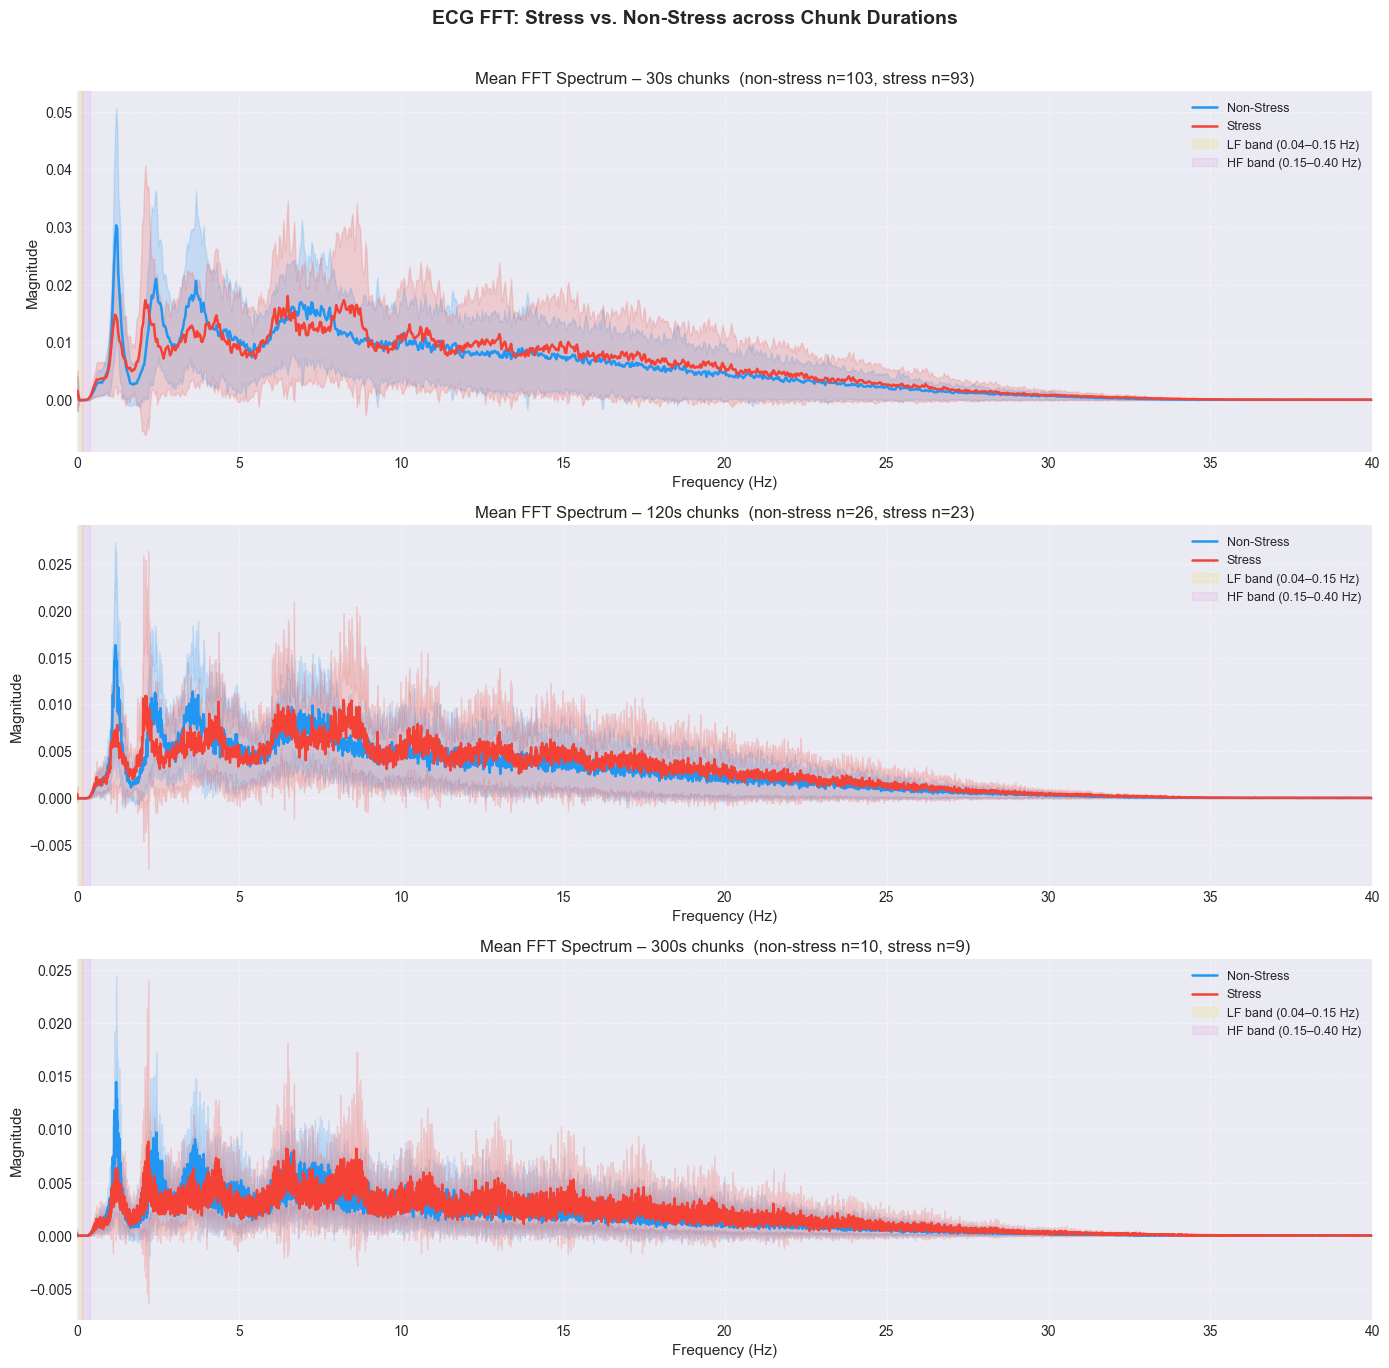

✅ Figure saved: fft_spectra_all_durations.png


In [12]:
fig, axes = plt.subplots(len(DURATIONS), 1, figsize=(14, 4.5 * len(DURATIONS)),
                         sharex=False)

for ax, duration in zip(axes, DURATIONS):
    res    = results[duration]
    freqs  = res['freqs']
    spectra = res['spectra']

    for bin_label, label_name in LABEL_NAME.items():
        mags = spectra[bin_label]
        if len(mags) == 0:
            continue
        arr  = np.stack(mags, axis=0)           # (n_chunks, n_freqs)
        mean = arr.mean(axis=0)
        std  = arr.std(axis=0)
        color = COLORS[bin_label]

        ax.plot(freqs, mean, color=color, lw=1.8, label=label_name)
        ax.fill_between(freqs, mean - std, mean + std,
                        color=color, alpha=0.18)

    # Mark classic HRV bands
    ax.axvspan(0.04, 0.15, color='gold',   alpha=0.12, label='LF band (0.04–0.15 Hz)')
    ax.axvspan(0.15, 0.40, color='orchid', alpha=0.12, label='HF band (0.15–0.40 Hz)')

    ax.set_xlim(0, FREQ_MAX)
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Magnitude', fontsize=11)
    ax.set_title(f'Mean FFT Spectrum – {duration}s chunks  '
                 f'(non-stress n={len(spectra[0])}, stress n={len(spectra[1])})',
                 fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, ls='--', alpha=0.4)

fig.suptitle('ECG FFT: Stress vs. Non-Stress across Chunk Durations',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('fft_spectra_all_durations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure saved: fft_spectra_all_durations.png')

## 4 · Overlay plot – all durations on same axes

This lets you see how increasing the chunk length smooths the spectrum.

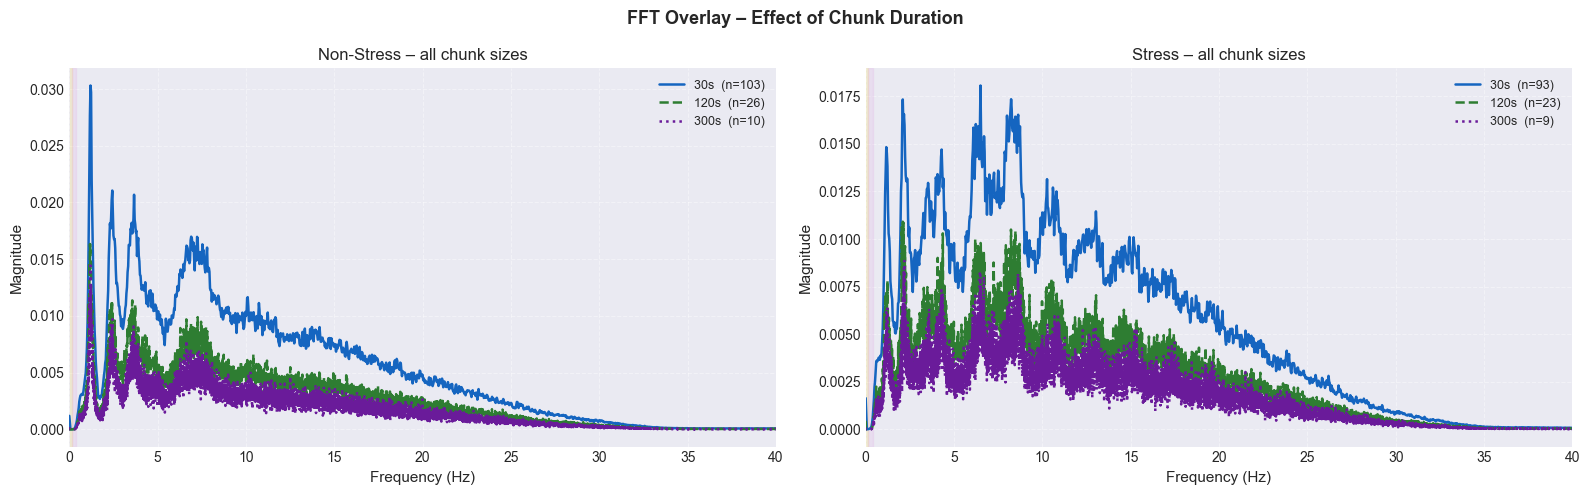

✅ Figure saved: fft_overlay_durations.png


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)

line_styles = {30: '-', 120: '--', 300: ':'}
duration_colors = {30: '#1565C0', 120: '#2E7D32', 300: '#6A1B9A'}

for bin_label, label_name in LABEL_NAME.items():
    ax = axes[bin_label]
    for duration in DURATIONS:
        res    = results[duration]
        freqs  = res['freqs']
        mags   = res['spectra'][bin_label]
        if len(mags) == 0:
            continue
        arr  = np.stack(mags, axis=0)
        mean = arr.mean(axis=0)
        ax.plot(freqs, mean,
                color=duration_colors[duration],
                ls=line_styles[duration],
                lw=1.8,
                label=f'{duration}s  (n={len(mags)})')

    ax.axvspan(0.04, 0.15, color='gold',   alpha=0.10)
    ax.axvspan(0.15, 0.40, color='orchid', alpha=0.10)
    ax.set_xlim(0, FREQ_MAX)
    ax.set_xlabel('Frequency (Hz)', fontsize=11)
    ax.set_ylabel('Magnitude', fontsize=11)
    ax.set_title(f'{label_name} – all chunk sizes', fontsize=12)
    ax.legend(fontsize=9)
    ax.grid(True, ls='--', alpha=0.4)

fig.suptitle('FFT Overlay – Effect of Chunk Duration', fontsize=13, fontweight='bold')
fig.tight_layout()
plt.savefig('fft_overlay_durations.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure saved: fft_overlay_durations.png')

## 5 · Cosine Similarity Analysis

**Three pairwise comparisons per chunk duration:**

| Comparison | Meaning |
|---|---|
| Stress ↔ Non-stress | Cross-class – should be **low** if FFT is discriminative |
| Stress ↔ Stress | Within stress – should be **high** |
| Non-stress ↔ Non-stress | Within non-stress – should be **high** |

We sample random pairs (up to `MAX_PAIRS`) to keep computation fast.

In [14]:
import random as _random
_random.seed(42)
np.random.seed(42)

MAX_PAIRS = 500   # max random pairs per comparison type (speed)


def cosine_similarity(a, b):
    """Return cosine similarity in [0, 1] between two non-negative magnitude vectors."""
    norm_a = np.linalg.norm(a)
    norm_b = np.linalg.norm(b)
    if norm_a == 0 or norm_b == 0:
        return np.nan
    return float(np.dot(a, b) / (norm_a * norm_b))


def sample_pairs(list_a, list_b, max_pairs, same_list=False):
    """
    Draw up to max_pairs random (i, j) pairs.
    If same_list=True we draw pairs where i < j (within-class).
    """
    sims = []
    if same_list:
        n = len(list_a)
        all_pairs = [(i, j) for i in range(n) for j in range(i + 1, n)]
    else:
        all_pairs = [(i, j) for i in range(len(list_a))
                     for j in range(len(list_b))]

    chosen = _random.sample(all_pairs, min(max_pairs, len(all_pairs)))

    for i, j in chosen:
        a = list_a[i]
        b = list_b[j] if not same_list else list_a[j]
        s = cosine_similarity(a, b)
        if not np.isnan(s):
            sims.append(s)
    return sims


# Compute similarities
cos_results = {}   # cos_results[duration] = {'cross': [...], 'stress': [...], 'nonstress': [...]}

for duration in DURATIONS:
    spec_ns = results[duration]['spectra'][0]   # non-stress spectra
    spec_s  = results[duration]['spectra'][1]   # stress spectra

    cross     = sample_pairs(spec_s, spec_ns, MAX_PAIRS, same_list=False)
    within_s  = sample_pairs(spec_s, spec_s,  MAX_PAIRS, same_list=True)
    within_ns = sample_pairs(spec_ns, spec_ns, MAX_PAIRS, same_list=True)

    cos_results[duration] = {
        'Stress ↔ Non-stress': cross,
        'Stress ↔ Stress'    : within_s,
        'Non-stress ↔ Non-stress': within_ns,
    }

    print(f'\n{duration}s chunks:')
    for comp_name, vals in cos_results[duration].items():
        if vals:
            print(f'   {comp_name:<28s}  mean={np.mean(vals):.4f}  '
                  f'std={np.std(vals):.4f}  n={len(vals)}')
        else:
            print(f'   {comp_name:<28s}  (no pairs)')

print('\n✅ Cosine similarity computation complete')


30s chunks:
   Stress ↔ Non-stress           mean=0.6420  std=0.1096  n=500
   Stress ↔ Stress               mean=0.6316  std=0.1151  n=500
   Non-stress ↔ Non-stress       mean=0.6924  std=0.0891  n=500

120s chunks:
   Stress ↔ Non-stress           mean=0.6563  std=0.0912  n=500
   Stress ↔ Stress               mean=0.6403  std=0.0928  n=253
   Non-stress ↔ Non-stress       mean=0.7020  std=0.0615  n=325

300s chunks:
   Stress ↔ Non-stress           mean=0.6633  std=0.0931  n=90
   Stress ↔ Stress               mean=0.6428  std=0.0855  n=36
   Non-stress ↔ Non-stress       mean=0.6987  std=0.0660  n=45

✅ Cosine similarity computation complete


## 6 · Plot cosine similarity distributions

**Subplot layout:**  
- Rows = chunk durations (30s / 120s / 300s)  
- Columns = comparison type (cross / within-stress / within-non-stress)  

Each panel shows a KDE + rug plot so you can see both the spread and individual pair values.

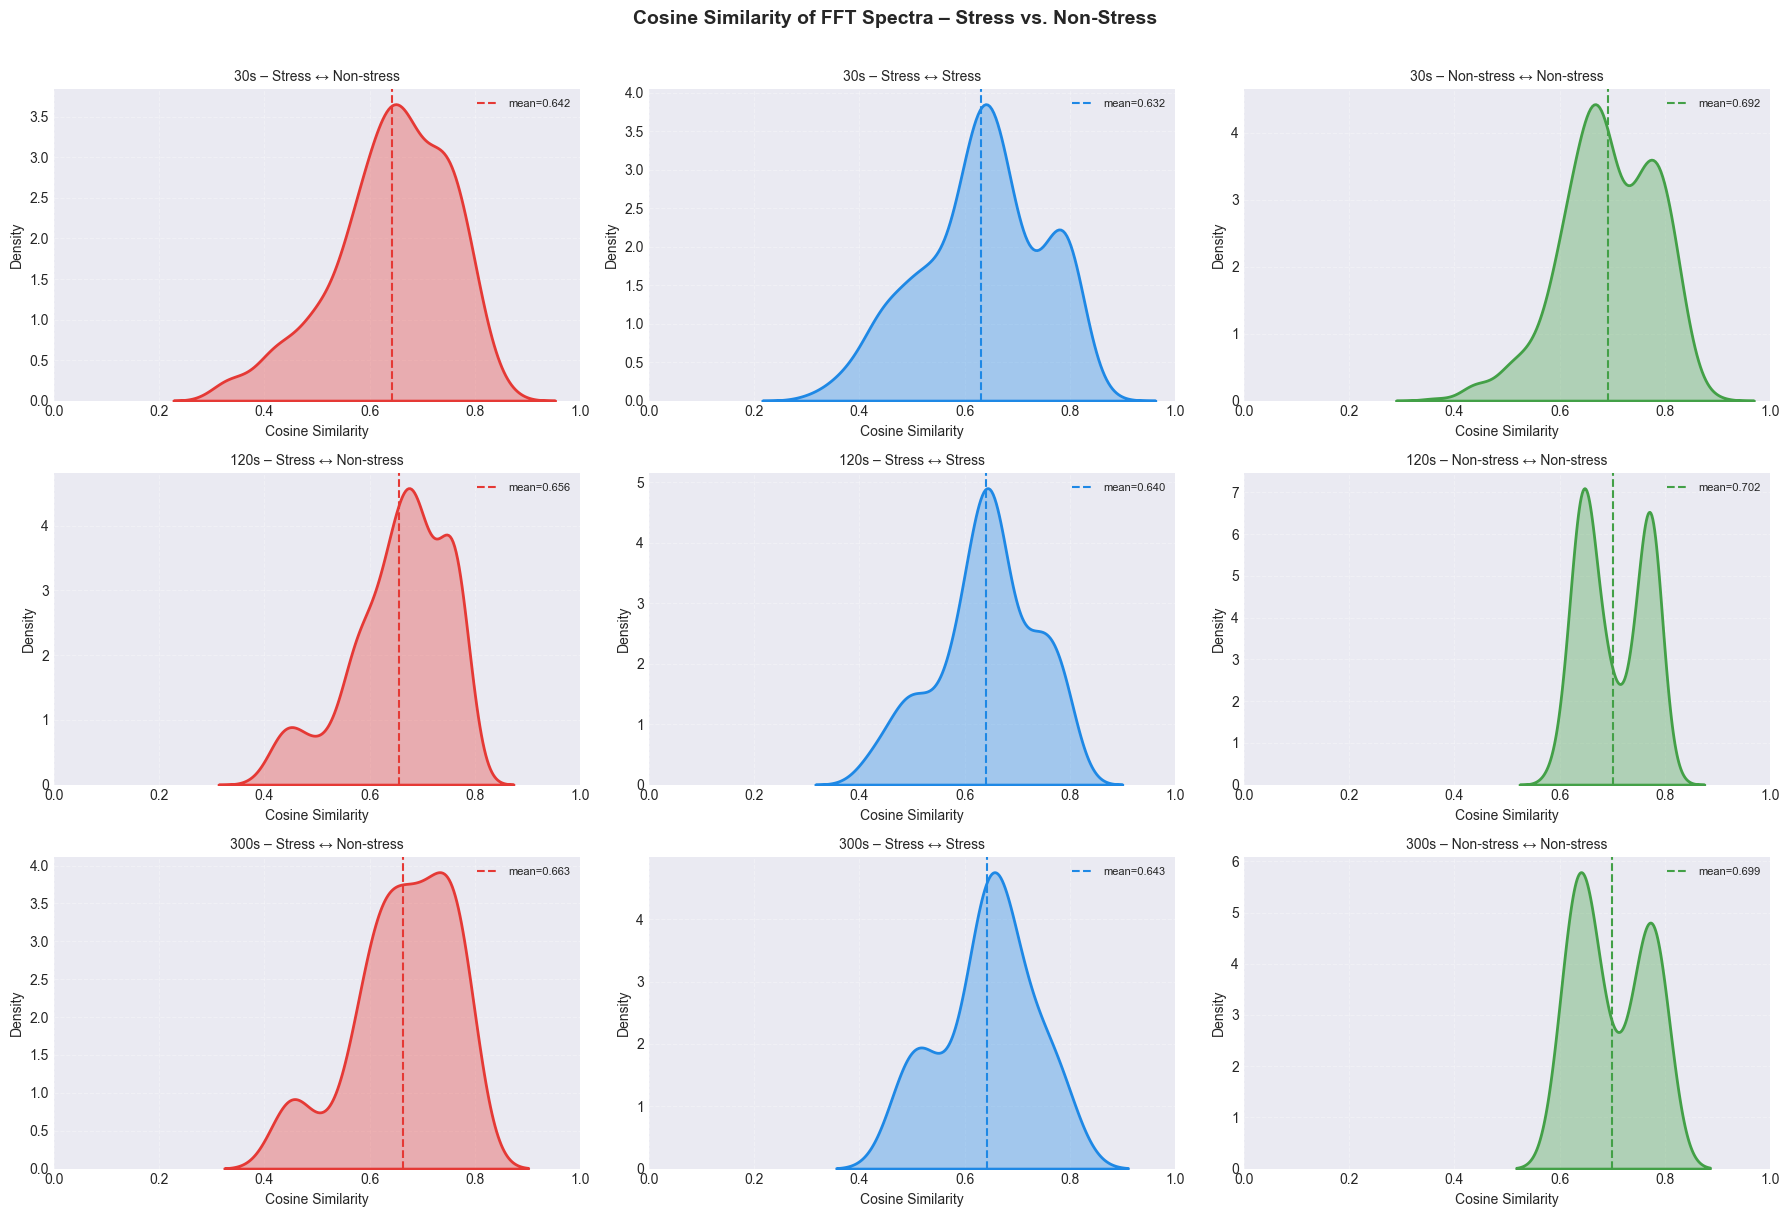

✅ Figure saved: fft_cosine_similarity_distributions.png


In [15]:
comp_names  = ['Stress ↔ Non-stress', 'Stress ↔ Stress', 'Non-stress ↔ Non-stress']
comp_colors = ['#E53935', '#1E88E5', '#43A047']

fig, axes = plt.subplots(len(DURATIONS), len(comp_names),
                         figsize=(18, 4 * len(DURATIONS)),
                         sharey=False)

for row, duration in enumerate(DURATIONS):
    for col, (comp, color) in enumerate(zip(comp_names, comp_colors)):
        ax   = axes[row][col]
        vals = cos_results[duration][comp]

        if vals:
            sns.kdeplot(vals, ax=ax, color=color, fill=True, alpha=0.35, lw=2)
            ax.axvline(np.mean(vals), color=color, lw=1.5, ls='--',
                       label=f'mean={np.mean(vals):.3f}')
            ax.set_xlim(0, 1)
            ax.legend(fontsize=8)
        else:
            ax.text(0.5, 0.5, 'No data', ha='center', va='center',
                    transform=ax.transAxes, fontsize=11)

        ax.set_xlabel('Cosine Similarity', fontsize=10)
        ax.set_ylabel('Density', fontsize=10)
        ax.set_title(f'{duration}s – {comp}', fontsize=10)
        ax.grid(True, ls='--', alpha=0.3)

fig.suptitle('Cosine Similarity of FFT Spectra – Stress vs. Non-Stress',
             fontsize=14, fontweight='bold', y=1.01)
fig.tight_layout()
plt.savefig('fft_cosine_similarity_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure saved: fft_cosine_similarity_distributions.png')

## 7 · Summary bar chart – mean cosine similarity per duration

One grouped bar chart showing all three comparison types across chunk durations, making it easy to see how **discriminability** (gap between cross vs. within) changes with window length.

Duration (s)              Comparison  Mean Cosine Similarity      Std  N pairs
         30s     Stress ↔ Non-stress                0.642004 0.109631      500
         30s         Stress ↔ Stress                0.631557 0.115150      500
         30s Non-stress ↔ Non-stress                0.692354 0.089113      500
        120s     Stress ↔ Non-stress                0.656270 0.091201      500
        120s         Stress ↔ Stress                0.640284 0.092833      253
        120s Non-stress ↔ Non-stress                0.701958 0.061524      325
        300s     Stress ↔ Non-stress                0.663297 0.093091       90
        300s         Stress ↔ Stress                0.642815 0.085489       36
        300s Non-stress ↔ Non-stress                0.698737 0.065988       45


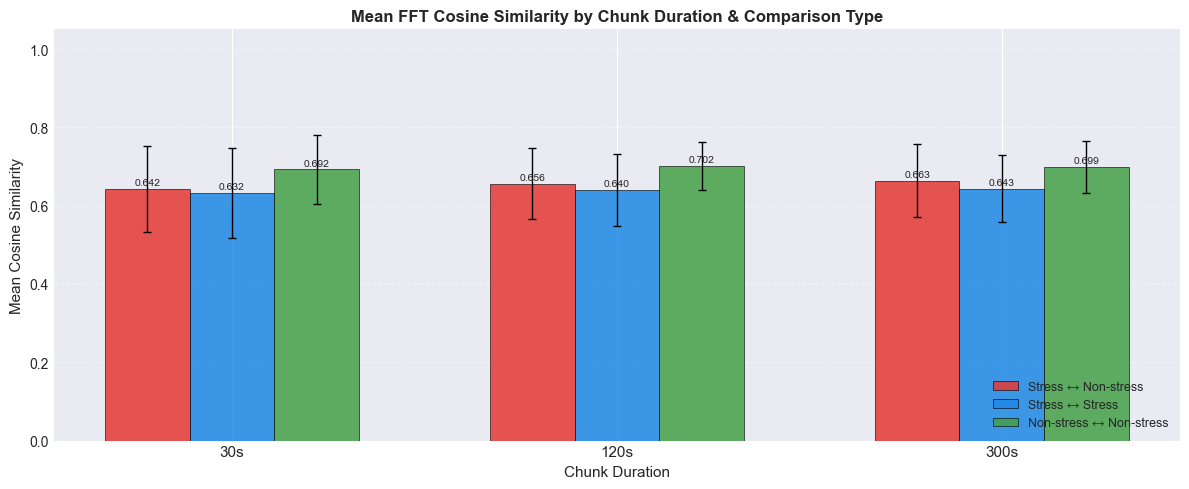

✅ Figure saved: fft_cosine_summary_bar.png
✅ CSV saved   : fft_cosine_summary.csv


In [16]:
summary_rows = []
for duration in DURATIONS:
    for comp in comp_names:
        vals = cos_results[duration][comp]
        summary_rows.append({
            'Duration (s)': f'{duration}s',
            'Comparison'  : comp,
            'Mean Cosine Similarity': np.mean(vals) if vals else np.nan,
            'Std'         : np.std(vals)  if vals else np.nan,
            'N pairs'     : len(vals),
        })

summary_df = pd.DataFrame(summary_rows)
print(summary_df.to_string(index=False))
summary_df.to_csv('fft_cosine_summary.csv', index=False)

# --- grouped bar chart ---
pivot = summary_df.pivot(index='Duration (s)', columns='Comparison',
                         values='Mean Cosine Similarity')

fig, ax = plt.subplots(figsize=(12, 5))
x      = np.arange(len(DURATIONS))
n_comp = len(comp_names)
width  = 0.22

for i, (comp, color) in enumerate(zip(comp_names, comp_colors)):
    vals_mean = []
    vals_std  = []
    for duration in DURATIONS:
        v = cos_results[duration][comp]
        vals_mean.append(np.mean(v) if v else np.nan)
        vals_std.append(np.std(v)   if v else np.nan)

    offset = (i - n_comp / 2 + 0.5) * width
    bars   = ax.bar(x + offset, vals_mean, width,
                    color=color, alpha=0.85, label=comp,
                    edgecolor='black', linewidth=0.5)
    ax.errorbar(x + offset, vals_mean, yerr=vals_std,
                fmt='none', color='black', capsize=3, lw=1)

    for bar, m in zip(bars, vals_mean):
        if not np.isnan(m):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.005,
                    f'{m:.3f}', ha='center', va='bottom', fontsize=7.5)

ax.set_xticks(x)
ax.set_xticklabels([f'{d}s' for d in DURATIONS], fontsize=11)
ax.set_xlabel('Chunk Duration', fontsize=11)
ax.set_ylabel('Mean Cosine Similarity', fontsize=11)
ax.set_ylim(0, 1.05)
ax.set_title('Mean FFT Cosine Similarity by Chunk Duration & Comparison Type',
             fontsize=12, fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.grid(axis='y', ls='--', alpha=0.4)

fig.tight_layout()
plt.savefig('fft_cosine_summary_bar.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Figure saved: fft_cosine_summary_bar.png')
print('✅ CSV saved   : fft_cosine_summary.csv')

## 8 · Interpretation guide

| Pattern | Interpretation |
|---|---|
| **Stress ↔ Non-stress** similarity is **low** | FFT shape differs between classes → useful discriminative feature |
| **Within-class** similarities are **high** | Spectral patterns are consistent within each class |
| Gap **increases** with chunk duration | Longer windows capture more stable frequency content |
| All three near **1.0** | Spectra are nearly identical → FFT alone may not discriminate well |

**HRV bands to watch:**
- **LF (0.04–0.15 Hz):** linked to sympathetic + parasympathetic activity.  
  Stress tends to **raise LF power**.
- **HF (0.15–0.40 Hz):** linked to parasympathetic / respiratory.  
  Stress tends to **lower HF power**.
- **LF/HF ratio:** classical stress biomarker – higher under stress.

These shifts should be visible as differences in the mean FFT plots in Section 3.